# Clustering với k-Means

In [20]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [21]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

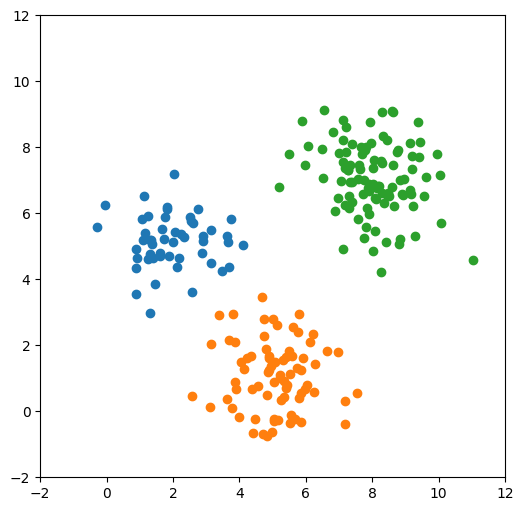

In [22]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [23]:
dat1 = np.stack([x1,y1]).T
dat1.shape


(50, 2)

In [24]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [25]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape


(225, 2)

### Sắp ngẫu nhiên các dòng

In [26]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

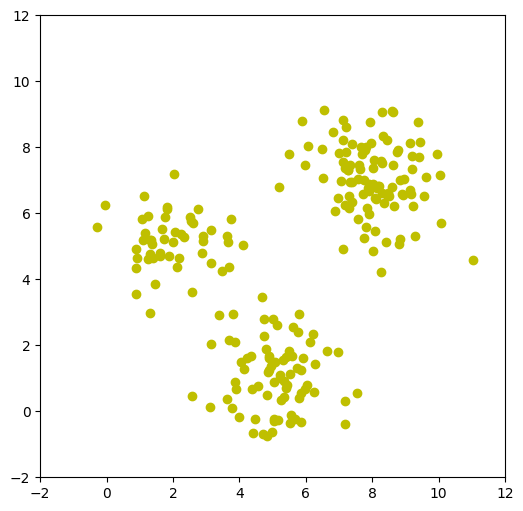

In [27]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [28]:
K = 3

In [29]:
np.random.seed(30)
idx = np.random.randint(low=0, high=225, size=K)
print(idx)


[ 37 165 173]


**Gán các trung tâm cho 3 điểm này**

In [30]:
centroids = dat[idx]
print(centroids)

[[2.051 5.423]
 [1.313 5.187]
 [7.132 7.564]]


**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

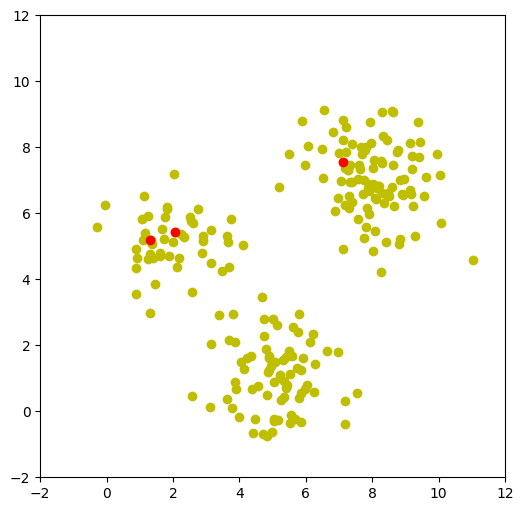

In [31]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='r')

plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [32]:
cList = [[] for _ in range(K)]

print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [33]:
for sample in dat:
     kq = np.sum((sample - centroids)**2, axis=1)
     min_d_idx = np.argmin(kq)
     cList[min_d_idx].append(sample)
    

In [34]:
# Thử kiểm tra lại mỗi list
for i in range(K): print(len(cList[i]))

98
24
103


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [35]:
np.stack(cList[0]).shape

(98, 2)

In [36]:
# Tọa độ của điểm centroid mới
np.stack(cList[0]).mean(axis=0)

array([4.374, 2.299])

**=== Tính lại các điểm centroids ===**

In [37]:
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)

print(centroids)

[[4.374 2.299]
 [1.269 4.555]
 [7.988 6.899]]


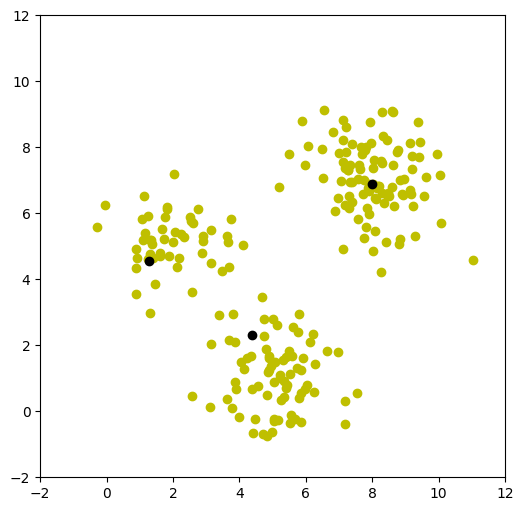

In [38]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [39]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.036 1.22 ]
 [1.861 5.185]
 [8.016 7.064]]


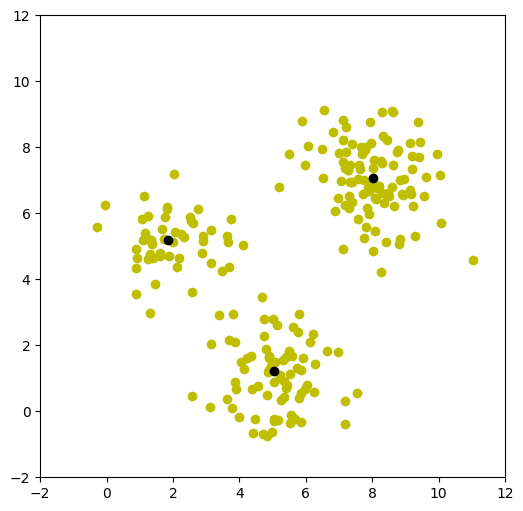

In [40]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [41]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.087 1.087]
 [1.974 5.147]
 [8.016 7.064]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [42]:
# Lấy ra các cluster
c1 = np.stack(cList[0])
c2 = np.stack(cList[1])
c3 = np.stack(cList[2])


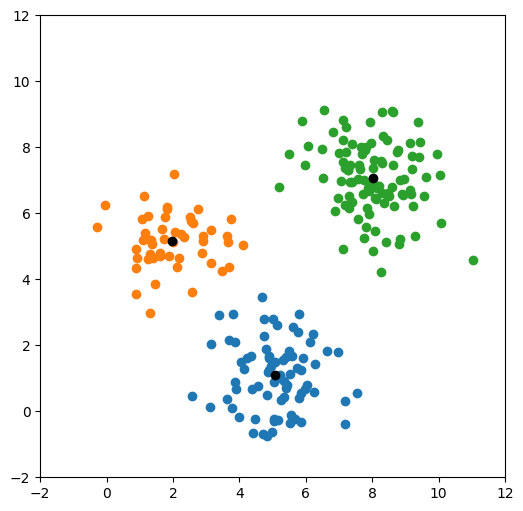

In [43]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(c1[:,0], c1[:,1])
plt.scatter(c2[:,0], c2[:,1])
plt.scatter(c3[:,0], c3[:,1])

plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()